In [1]:
import numpy as np
import psfsim
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.interpolate as sp_itp

from psfsim.polychrom import PolychromaticPSF

In [2]:
j129 = np.linspace( 1.131, 1.454, 10 ) # microns

# PSF generation and downsampling parameters
ps_size = 96
ovsamp = pixel_size = 8
mag = 1e9 # some unit

# Poisson resampling and spike fitting parameters
step = 0.1 # degrees
borders = ( 0.2, 1. )
bound = ps_size // 2
center = np.array( ( ps_size // 2, ps_size // 2 ) )
flux_factor = pixel_size**2 * mag

# Interpolation parameters
dense_ps_size = 600
dense_bound = dense_ps_size // 2
dense_center = np.array( ( dense_ps_size // 2, dense_ps_size // 2 ) )

In [3]:
def line_coords( angle, bound, center=np.array( ( 0, 0 ) ) ):
    # since (0, 0) in data coords is top left instead of bottom left we must use clockwise rotations to get
    # a visually ccl rotation. However we will take a transpose later anyways so the rotation matrix def is ccl, as expected. How quaint
    angle = np.deg2rad( angle )
    # print( angle )
    line = np.zeros( ( 2, bound ) )
    line[0] = np.arange( bound )

    rotation = np.array( (
        ( np.cos( angle ), -np.sin( angle ) ),
        ( np.sin( angle ), np.cos( angle ) ),
    ) )

    if len( rotation.shape ) > 2:
        line = line.reshape( ( 1, 2, bound ) )

    # print( line.shape )
    # print( rotation.T.shape )
    
    return np.int32( rotation.T @ line ) + np.int32( np.reshape( center, ( 2, 1 ) ) )

def find_spikes( image, step, bound=1024, center=np.array( ( 0, 0 )  ), borders=( 0., 1. ), threshold=0.5, verbose=False ):
    angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )

    lines = line_coords( angles, bound, center )
    image_analyze = image.T # imshow will display the image as row,col with 0,0 in top left. For our analysis we want (col,row).
    
    line_vals = image_analyze[ lines[:,0], lines[:,1] ]
    sums = np.sum( line_vals, axis=-1 )

    # 0 to 1 for these. Should I add a way to make it force 0 <= borders[0] < borders[1] <= 1?
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )

    sums = np.sum( line_vals[:, range_low:range_high ], axis=-1 )    
    '''
    This formula is slightly different from the midpoint formula from before. The formula defaults to the 60% value, using 50% recovers the original behavior. Other
    ways to do this include rejecting the lowest 10% of values or so. That one might be worth pursuing in the future. The goal is to keep this method as simple as possible--
    I do NOT want to start staring at noise to find spikes.

    There is another method that may be worth pursuing that involves a boxcar average that goes around the circle and might be able to correct for groups of spikes that are much
    higher or lower than the naive cutoff assumes.
    '''
    diff = np.max( sums ) - np.min( sums )
    cutoff = np.min( sums ) + ( diff * threshold )
    spike_indices = np.where( sums > cutoff )[0]
    spike_angles = angles[ spike_indices ]
    # print( np.diff( spike_angles ) )

    # try 3 degrees to tell differing spikes apart for now
    spike_angle_discriminator = 3.
    borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
    spike_groups = np.split( spike_angles, borders + 1 )
    # print( spike_groups )

    # unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
    spike_list = np.zeros( len( spike_groups ) )
    for i in np.arange( len( spike_groups ) ):
        spike_list[i] = np.median( spike_groups[i] )

    # print( spike_list )
    if verbose:
        return sums, spike_angles, cutoff, spike_list
    else:
        return spike_list

def draw_ray( ax, angle, bound, center=np.array( ( 0, 0 ) ), borders=( 0., 1. ), **kwargs ):
    line = line_coords( angle, bound, center )
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )
    ax.plot( line[ 0, range_low:range_high ], line[ 1, range_low:range_high ], **kwargs )
    return

def downsample_2d_image( image, pixel_size=8 ): # ONLY WORKS ON 2D IMAGES
    subpixel_side = np.arange( pixel_size )
    subpixel_cols, subpixel_rows = np.meshgrid( subpixel_side, subpixel_side )

    dsamp_size = image.shape[0] // pixel_size
    pixels_side = np.arange( dsamp_size ) * pixel_size
    pixels_cols, pixels_rows = np.meshgrid( pixels_side, pixels_side )
    
    pixels_rows = pixels_rows[ :, :, np.newaxis ] # promote to 3D
    pixels_cols = pixels_cols[ :, :, np.newaxis ]
    
    idx_arr_subpixel_rows = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_rows.flatten( ) )
    idx_arr_subpixel_cols = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_cols.flatten( ) )
    
    idx_arr_rows = idx_arr_subpixel_rows + pixels_rows
    idx_arr_cols = idx_arr_subpixel_cols + pixels_cols
    
    pixelated_image = image[ idx_arr_rows, idx_arr_cols ]
    downsampled_image = np.mean( pixelated_image, axis=-1 )
    return downsampled_image

def poisson_resample_image( img, flux_factor ):
    # resamples an image where each pixel gets its own poisson distribution
    # this will change the scales around so that the resulting image has large positive values!!!! be aware
    rng = np.random.default_rng( )
    poisson_means = img * flux_factor

    resampled_img = rng.poisson( poisson_means, size=poisson_means.shape )
    return resampled_img

def interpolate_image( img, dense_size ): # 2D ONLY
    x_pts = np.arange( img.shape[0] )
    y_pts = np.arange( img.shape[1] )

    new_grid = sp_itp.RegularGridInterpolator( ( x_pts, y_pts ), img, method='linear' )
    dense_x_1d = np.linspace( 0, img.shape[0] - 1, dense_size )
    dense_y_1d = np.linspace( 0, img.shape[1] - 1, dense_size )
    dense_x, dense_y = np.meshgrid( dense_x_1d, dense_y_1d, indexing='ij' )

    return new_grid( ( dense_x, dense_y ) )

In [4]:
def compute_response_matrix( aberrations, ideal_spike_angles, psf_object, step, bound, center, **kwargs ):
    resp_matrix = np.zeros( ( 12, 5 ) )
    for i in np.arange( aberrations.size ):
        extra_aberrations = [ None, None, None, None, None ]
        extra_aberrations[i] = aberrations[i]
        
        psf_object.compute_poly_psf(
            postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
            ovsamp=8, extra_aberrations=extra_aberrations
        )
        
        psf_ovsamp = np.log10( np.abs( psf_object.chromatic_psf ) )
        psf_dsamp = downsample_2d_image( psf_ovsamp, pixel_size=8 )
        psf = interpolate_image( psf_dsamp, dense_ps_size )
    
        spike_list = find_spikes( psf, step, bound, center, **kwargs )
        resp_matrix[:, i] = ( spike_list - ideal_spike_angles ) / aberrations[i]

    return resp_matrix

In [5]:
j129_obj = PolychromaticPSF( 9,0,0, j129 )

j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129' )
psf_ideal = interpolate_image( 
    np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) ), dense_ps_size )

ideal_spikes = find_spikes( psf_ideal, step, dense_bound, dense_center, borders=borders )
print( ideal_spikes )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
[ 10.8   49.4   72.25 110.2  133.7  165.6  191.9  228.   252.55 291.25
 314.05 344.75]


In [6]:
aberrations = np.full( 5, 0.04 )
resp_matrix_04 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.07 )
resp_matrix_07 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.1 )
resp_matrix_10 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.13 )
resp_matrix_13 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [7]:
rng = np.random.default_rng( )

# test_aberrations = [ 0.085, 0, 0, 0.1, 0 ]
test_aberrations = ( rng.random( 5 ) * 0.2 ) - 0.1
# test_aberrations[ 1: ] = 0
print( f'Test Aberration Values: {test_aberrations}' )


j129_obj.compute_poly_psf(
    optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
    use_filter='J129', extra_aberrations=test_aberrations
)
test_psf = interpolate_image( 
    np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) ), dense_ps_size )

Test Aberration Values: [-0.09711594 -0.06719695 -0.00087082  0.03914692 -0.07138338]


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


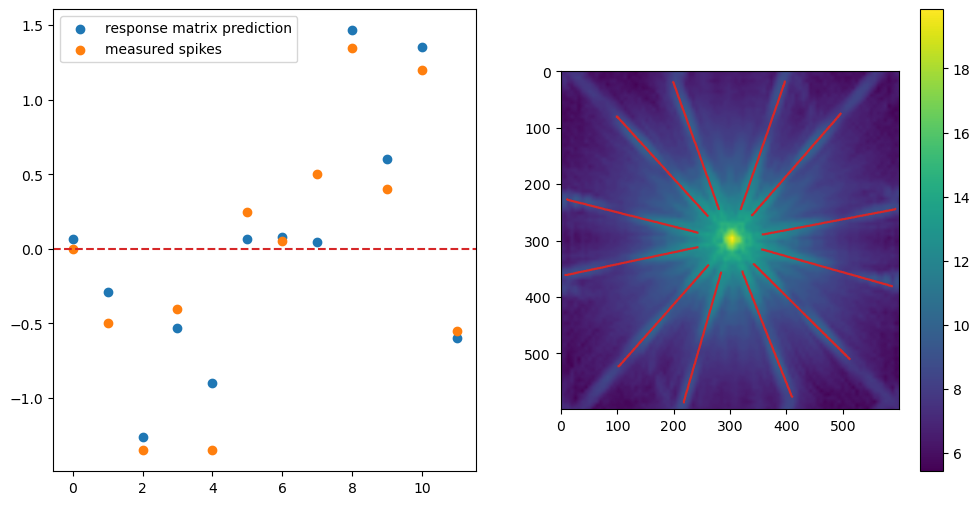

In [8]:
big_resp_matrix = np.zeros( ( 12, 5, 4 ) )
big_resp_matrix[ :, :, 0 ] = resp_matrix_04
big_resp_matrix[ :, :, 1 ] = resp_matrix_07
big_resp_matrix[ :, :, 2 ] = resp_matrix_10
big_resp_matrix[ :, :, 3 ] = resp_matrix_13
resp_matrix = np.mean( big_resp_matrix, axis=-1 )


predict_angle_diffs = resp_matrix @ np.array( test_aberrations )
spike_list_test = find_spikes( test_psf, step, dense_bound, dense_center, borders=borders )

dth_vec = spike_list_test - ideal_spikes
# predict_aberrations = np.linalg.inv( resp_matrix.T @ resp_matrix ) @ resp_matrix.T @ dth_vec
N = np.arange( spike_list_test.size )

# print( predict_aberrations )

fig, ax = plt.subplots( figsize=( 12, 6 ), ncols=2 )

ax[0].scatter( N, predict_angle_diffs, label='response matrix prediction' )
ax[0].scatter( N, dth_vec, label='measured spikes' )
ax[0].axhline( 0, color='C3', ls='--' )
ax[0].legend( )

im = ax[1].imshow( test_psf )
fig.colorbar( im, ax=ax[1] )

# with np.printoptions( precision=4, floatmode='fixed' ):
#     ax[1].set_title( f'{test_aberrations}' )

for s in spike_list_test:
    draw_ray( ax[1], s, dense_bound, dense_center, borders=borders, color='C3' )

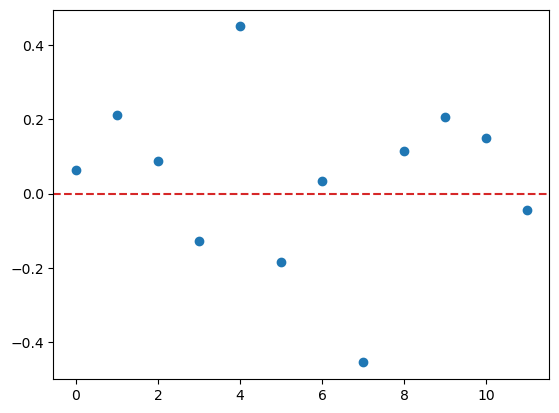

In [9]:
plt.scatter( N, predict_angle_diffs - dth_vec )
plt.axhline( 0, color='C3', ls='--' )

In [10]:
n = 15
N = np.full( ( 15, 12 ), np.arange( 12 )[ np.newaxis, : ] )
print( N )

[[ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]]


In [11]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


[[ 1.5   1.05  0.55  1.3  -0.1  -1.35 -0.45 -1.25 -1.75 -0.2  -0.1   0.1 ]
 [ 1.5   1.1   0.7   1.4  -0.05 -1.35 -0.5  -1.3  -1.8  -0.25 -0.1   0.  ]
 [ 1.55  1.1   0.7   1.45  0.05 -1.3  -0.55 -1.3  -1.95 -0.3  -0.15  0.  ]
 [ 1.6   1.15  0.75  1.5   0.   -1.3  -0.6  -1.35 -2.   -0.35 -0.15  0.  ]
 [ 1.55  1.2   0.85  1.6  -0.05 -1.3  -0.6  -1.45 -2.05 -0.35 -0.2   0.  ]
 [ 1.55  1.25  0.9   1.65  0.05 -1.25 -0.5  -1.45 -2.15 -0.35 -0.3   0.  ]
 [ 1.55  1.25  0.95  1.65  0.1  -1.25 -0.55 -1.5  -2.25 -0.4  -0.35  0.  ]
 [ 1.6   1.25  1.    1.75  0.   -1.25 -0.55 -1.55 -2.4  -0.55 -0.35  0.  ]
 [ 1.6   1.4   1.05  1.85  0.1  -1.1  -0.65 -1.6  -2.45 -0.6  -0.4   0.  ]
 [ 1.65  1.45  1.15  1.85  0.3  -1.1  -0.65 -1.65 -2.45 -0.65 -0.55  0.  ]
 [ 1.65  1.5   1.2   2.    0.35 -1.1  -0.65 -1.65 -2.5  -0.75 -0.55 -0.05]
 [ 1.65  1.55  1.2   2.    0.45 -1.1  -0.65 -1.7  -2.55 -0.85 -0.55 -0.05]
 [ 1.6   1.55  1.5   2.15  0.55 -1.1  -0.65 -1.8  -2.65 -0.95 -0.6  -0.05]
 [ 1.65  1.6   1.6   2.15

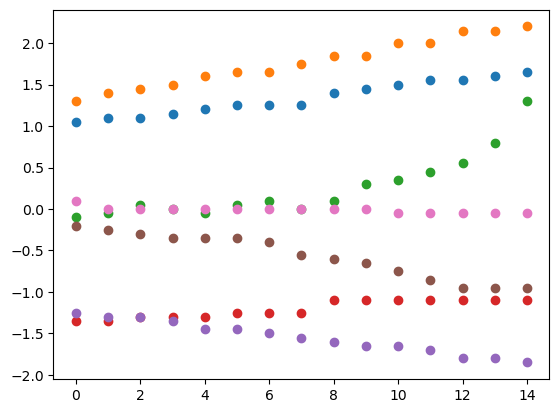

In [12]:
print( dth_mat )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat[ :, 1 ] )
ax.scatter( a, dth_mat[ :, 3 ] )
ax.scatter( a, dth_mat[ :, 4 ] )
ax.scatter( a, dth_mat[ :, 5 ] )
ax.scatter( a, dth_mat[ :, 7 ] )
ax.scatter( a, dth_mat[ :, 9 ] )
ax.scatter( a, dth_mat[ :, 11 ] )

# for i in np.arange( n )[:4]:
#     ax.scatter( np.arange( spike_count ), dth_mat[i] )

In [13]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_vcenter = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_vcenter[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


[[ 1.4   1.    0.5   1.25 -0.15 -1.35 -0.35 -1.2  -1.75 -0.1  -0.1  -0.05]
 [ 1.35  1.    0.5   1.35  0.05 -1.1  -0.35 -1.15 -1.65 -0.1  -0.1  -0.05]
 [ 1.25  0.9   0.5   1.35  0.1  -1.05 -0.25 -1.05 -1.65 -0.1  -0.15 -0.05]
 [ 1.2   0.85  0.45  1.35  0.1  -1.   -0.1  -0.95 -1.7  -0.15 -0.15 -0.1 ]
 [ 1.15  0.8   0.35  1.35  0.15 -0.85 -0.1  -0.95 -1.65 -0.15 -0.15 -0.2 ]
 [ 1.1   0.75  0.4   1.35  0.15 -0.8  -0.05 -0.9  -1.6  -0.15 -0.25 -0.3 ]
 [ 1.1   0.7   0.35  1.4   0.25 -0.75  0.   -0.8  -1.65 -0.2  -0.25 -0.4 ]
 [ 0.95  0.7   0.35  1.4   0.25 -0.7   0.15 -0.8  -1.6  -0.2  -0.3  -0.45]
 [ 0.9   0.6   0.3   1.4   0.25 -0.65  0.2  -0.8  -1.6  -0.2  -0.3  -0.55]
 [ 0.85  0.55  0.3   1.5   0.3  -0.7   0.3  -0.8  -1.7  -0.2  -0.3  -0.75]
 [ 0.75  0.55  0.25  1.5   0.3  -0.5   0.3  -0.8  -1.7  -0.2  -0.45 -0.75]
 [ 0.55  0.55  0.25  1.5   0.3  -0.5   0.45 -0.8  -1.7  -0.25 -0.55 -0.75]
 [ 0.55  0.5   0.25  1.5   0.45 -0.35  0.45 -0.75 -1.65 -0.25 -0.6  -0.75]
 [ 0.55  0.5   0.2   1.55

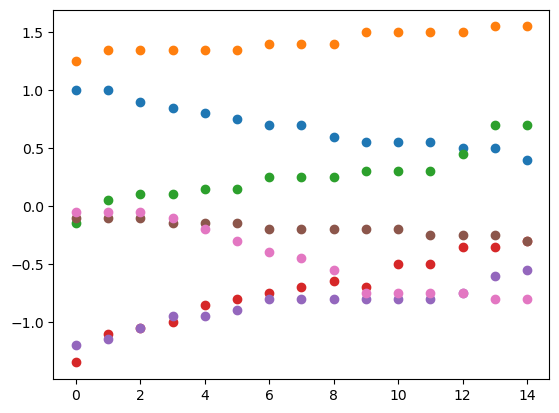

In [14]:
print( dth_mat_vcenter )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_vcenter[ :, 1 ] )
ax.scatter( a, dth_mat_vcenter[ :, 3 ] )
ax.scatter( a, dth_mat_vcenter[ :, 4 ] )
ax.scatter( a, dth_mat_vcenter[ :, 5 ] )
ax.scatter( a, dth_mat_vcenter[ :, 7 ] )
ax.scatter( a, dth_mat_vcenter[ :, 9 ] )
ax.scatter( a, dth_mat_vcenter[ :, 11 ] )

In [15]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_focus = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_focus[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


[[ 1.3   1.1   0.7   1.2  -0.5  -1.05 -0.35 -1.3  -1.85  0.    0.05 -0.05]
 [ 1.2   1.2   0.85  1.05 -1.1  -0.85 -0.1  -1.45 -2.05  0.15  0.2  -0.25]
 [ 1.1   1.35  0.95  0.95 -1.25 -0.7  -0.05 -1.55 -2.2   0.25  0.4  -0.45]
 [ 0.9   1.5   1.1   0.85 -1.3  -0.65  0.1  -1.7  -2.25  0.3   0.5  -0.75]
 [ 0.75  1.6   1.2   0.7  -1.8  -0.45  0.3  -1.8  -2.55  0.55  0.6  -0.8 ]
 [ 0.55  1.7   1.6   0.6  -1.85 -0.35  0.4  -1.9  -2.65  0.6   0.75 -0.9 ]
 [ 0.55  1.8   1.6   0.5  -1.9  -0.1   0.55 -1.95 -2.65  0.8   0.95 -0.9 ]
 [ 0.45  2.    1.7   0.35 -1.95  0.    0.65 -2.05 -2.75  0.9   0.95 -1.05]
 [ 0.25  2.15  1.75  0.25 -2.05  0.2   0.7  -2.3  -3.    1.05  1.25 -1.05]
 [ 0.15  2.15  1.85  0.25 -2.3   0.35  0.9  -2.4  -3.05  1.1   1.35 -1.45]
 [ 0.05  2.25  2.15  0.   -2.4   0.55  1.   -2.55 -3.2   1.2   1.4  -1.7 ]
 [-0.15  2.25  2.45 -0.05 -2.5   0.55  1.15 -2.6  -3.4   1.35  1.55 -1.85]
 [-0.2   2.4   2.6  -0.5  -2.65  0.75  1.45 -2.9  -3.45  1.5   1.8  -2.05]
 [-0.3   2.6   2.9  -0.6 

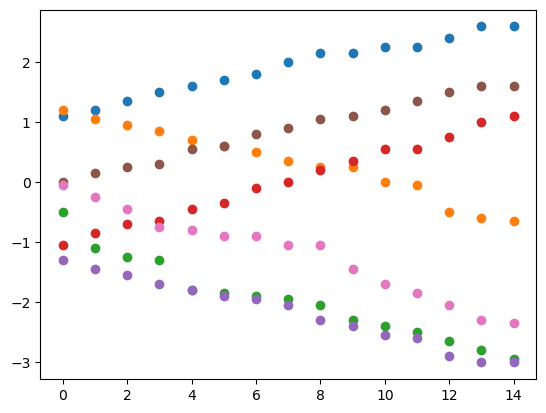

In [16]:
print( dth_mat_focus )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_focus[ :, 1 ] )
ax.scatter( a, dth_mat_focus[ :, 3 ] )
ax.scatter( a, dth_mat_focus[ :, 4 ] )
ax.scatter( a, dth_mat_focus[ :, 5 ] )
ax.scatter( a, dth_mat_focus[ :, 7 ] )
ax.scatter( a, dth_mat_focus[ :, 9 ] )
ax.scatter( a, dth_mat_focus[ :, 11 ] )

In [17]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_z5 = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_z5[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


[[ 1.6   1.    0.5   1.25 -0.6  -1.3  -0.65 -1.15 -1.65 -0.05 -0.05  0.  ]
 [ 1.6   0.85  0.5   1.25 -1.1  -1.25 -0.7  -0.9  -1.65 -0.05  0.1  -0.05]
 [ 1.75  0.75  0.35  1.2  -1.15 -1.05 -0.75 -0.9  -1.5   0.    0.2  -0.05]
 [ 1.8   0.65  0.35  1.2  -1.3  -0.9  -0.75 -0.8  -1.5   0.05  0.4  -0.15]
 [ 1.9   0.55  0.35  1.15 -1.3  -0.85 -0.85 -0.7  -1.45  0.05  0.5  -0.2 ]
 [ 1.9   0.5   0.35  1.1  -1.6  -0.8  -0.85 -0.65 -1.45  0.1   0.6  -0.35]
 [ 1.95  0.45  0.35  1.05 -1.75 -0.75 -0.9  -0.6  -1.45  0.1   0.6  -0.45]
 [ 1.95  0.35  0.3   0.95 -1.8  -0.7  -0.95 -0.4  -1.4   0.2   0.75 -0.55]
 [ 2.    0.15  0.25  0.95 -1.85 -0.7  -0.95 -0.35 -1.35  0.25  0.75 -0.55]
 [ 2.2   0.1   0.2   0.95 -1.85 -0.5  -1.15 -0.25 -1.35  0.25  0.95 -0.6 ]
 [ 2.2   0.05  0.2   0.9  -1.95 -0.45 -1.15 -0.2  -1.3   0.3   0.95 -0.7 ]
 [ 2.3  -0.05  0.2   0.85 -1.95 -0.4  -1.25 -0.05 -1.25  0.3   1.15 -0.9 ]
 [ 2.35 -0.05  0.2   0.8  -1.95 -0.3  -1.25  0.   -1.25  0.3   1.3  -0.9 ]
 [ 2.35 -0.05  0.05  0.75

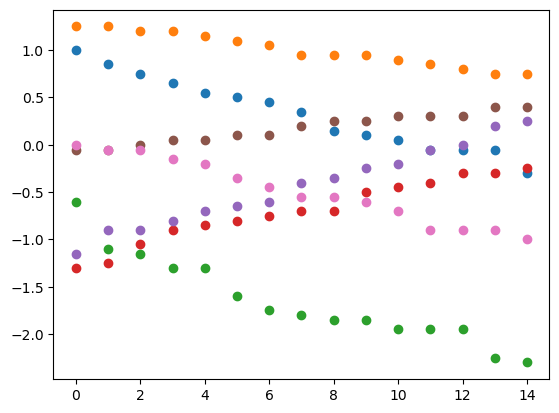

In [18]:
print( dth_mat_z5 )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_z5[ :, 1 ] )
ax.scatter( a, dth_mat_z5[ :, 3 ] )
ax.scatter( a, dth_mat_z5[ :, 4 ] )
ax.scatter( a, dth_mat_z5[ :, 5 ] )
ax.scatter( a, dth_mat_z5[ :, 7 ] )
ax.scatter( a, dth_mat_z5[ :, 9 ] )
ax.scatter( a, dth_mat_z5[ :, 11 ] )

In [19]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_z6 = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, None, None, aberration_arr[i] )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_z6[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


[[ 1.55  1.    0.65  1.25 -0.2  -1.4  -0.65 -1.2  -1.75  0.   -0.1   0.15]
 [ 1.65  1.    0.75  1.2  -0.1  -1.5  -0.7  -1.2  -1.85  0.05 -0.1   0.4 ]
 [ 1.75  1.    0.85  1.1   0.   -1.5  -0.75 -1.25 -2.05  0.1  -0.1   0.4 ]
 [ 1.8   1.    0.95  0.95 -0.05 -1.5  -0.75 -1.25 -2.15  0.2  -0.15  0.45]
 [ 1.8   1.    1.    0.95  0.05 -1.6  -0.85 -1.2  -2.25  0.3  -0.15  0.5 ]
 [ 2.    1.    1.1   0.9   0.   -2.05 -0.85 -1.15 -2.25  0.3  -0.15  0.5 ]
 [ 2.    0.95  1.2   0.85 -0.1  -2.05 -1.   -1.2  -2.3   0.4  -0.15  0.65]
 [ 2.1   1.    1.5   0.8  -0.05 -2.15 -1.1  -1.2  -2.55  0.4  -0.15  0.8 ]
 [ 2.25  0.95  1.6   0.75  0.05 -2.25 -1.15 -1.1  -2.65  0.45 -0.15  0.85]
 [ 2.3   0.95  1.6   0.6   0.15 -2.45 -1.25 -1.1  -2.65  0.6  -0.15  0.9 ]
 [ 2.35  0.95  1.7   0.55  0.   -2.65 -1.4  -1.1  -2.65  0.7  -0.15  1.  ]
 [ 2.5   0.95  1.75  0.45  0.2  -2.7  -1.4  -1.2  -2.7   0.8  -0.2   1.05]
 [ 2.55  0.9   1.85  0.3   0.1  -2.8  -1.45 -1.1  -2.7   0.85 -0.2   1.15]
 [ 2.6   0.9   1.95  0.25

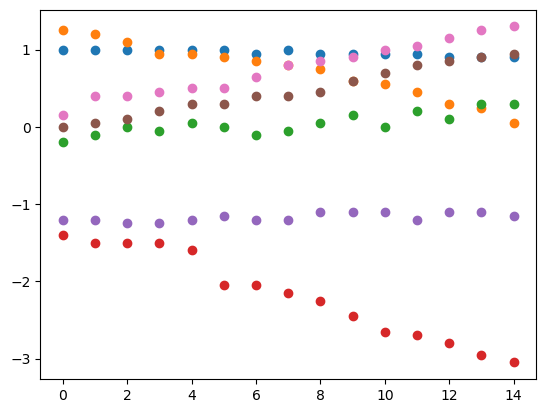

In [20]:
print( dth_mat_z6 )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_z6[ :, 1 ] )
ax.scatter( a, dth_mat_z6[ :, 3 ] )
ax.scatter( a, dth_mat_z6[ :, 4 ] )
ax.scatter( a, dth_mat_z6[ :, 5 ] )
ax.scatter( a, dth_mat_z6[ :, 7 ] )
ax.scatter( a, dth_mat_z6[ :, 9 ] )
ax.scatter( a, dth_mat_z6[ :, 11 ] )